<a href="https://colab.research.google.com/github/Tinnnn-vn/Neural-Network/blob/main/U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nhập nguồn dữ liệu từ kaggle
import kagglehub
ipythonx_carvana_image_masking_png_path = kagglehub.dataset_download('ipythonx/carvana-image-masking-png')
print('Data source import complete.')


100%|██████████| 828M/828M [00:10<00:00, 79.1MB/s]

Extracting files...


Data source import complete.


In [ ]:
# 1: Tạo ra một Bộ nạp dữ liệu (Dataset) tùy chỉnh bằng thư viện PyTorch.
# Dataset: Người quản lý kho (biết ảnh ở đâu, lấy ra thế nào)
import os # Dùng để làm việc với hệ điều hành (như lấy tên file, nối đường dẫn thư mục)
from PIL import Image # Thư viện xử lý hình ảnh (mở ảnh, xoay, cắt...)
from torch.utils.data import Dataset # Đây là "khung xương" của PyTorch. Chúng ta kế thừa nó để tạo ra bộ dữ liệu riêng
import numpy as np # Thư viện toán học, giúp chuyển ảnh thành các con số (ma trận) để máy tính hiểu được

# Load ảnh và mask cho bài toán segmentation, ví dụ tách xe ra khỏi nền
class CarvanaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir # Lưu đường dẫn thư mục chứa ảnh gốc
        self.mask_dir = mask_dir # Lưu đường dẫn thư mục chứa ảnh mask (kết quả mong muốn)
        self.transform = transform # Các phép biến đổi ảnh (như phóng to, thu nhỏ, làm nét)
        # Lấy danh sách tên file trong thư mục ảnh, loại bỏ đuôi '.jpg' để dễ quản lý (vd: 00087a6bd4dc_01)
        self.images = [f.replace('.jpg', '') for f in os.listdir(image_dir)]

    def __len__(self):
        return len(self.images) # Trả về tổng số lượng ảnh có trong bộ dữ liệu

    # Lấy tên file từ danh sách self.images, tạo đường dẫn đầy đủ cho ảnh và mask tương ứng
    def __getitem__(self, index):
        img_name = self.images[index] # Lấy tên của ảnh dựa vào số thứ tự (index)
        # Tạo đường dẫn đầy đủ đến file ảnh và file mask
        img_path = os.path.join(self.image_dir, img_name + ".jpg")
        mask_path = os.path.join(self.mask_dir, img_name + ".png")

        # Mở ảnh gốc, chuyển về hệ màu RGB và đưa về dạng mảng numpy
        image = np.array(Image.open(img_path).convert("RGB"))
        # Mở ảnh mask, chuyển về hệ màu xám (L) và định dạng số thực (float32)
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
        # Chuẩn hóa mask: Chỗ nào màu trắng (255) thì chuyển thành số 1, chỗ đen (0) giữ là 0. Chỗ này giúp máy tính hiểu: 1 là "xe", 0 là "nền"
        mask[mask == 255.0] = 1.0

        # Nếu có yêu cầu biến đổi dữ liệu (ví dụ: xoay ảnh, tăng sáng) thì thực hiện ở đây
        if self.transform:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]

        # Trả về ảnh và mask
        return image, mask

        '''__init__: Bạn chuẩn bị một rổ ảnh xe và một rổ hình vẽ đồ lại bóng của cái xe đó.
           __len__: Đứa trẻ hỏi "Có bao nhiêu tấm ảnh hả thầy?", bạn trả lời con số cụ thể.
           __getitem__: Bạn thò tay vào rổ lấy ra tấm ảnh số 5 (ảnh thật) và tấm bóng số 5 (mask), lau chùi sạch sẽ rồi đưa cho đứa trẻ xem.'''

In [ ]:
# 2: Trong Deep Learning, chúng ta không đưa ảnh thô vào máy tính. Thay vào đó, ta cần đưa chúng về một chuẩn chung (cùng kích thước, cùng khoảng giá trị số)
# Transform: Đầu bếp (cắt thái, rửa sạch, chuẩn hóa ảnh)
import albumentations as A #Thư viện dùng để biến đổi hình ảnh (tăng cường dữ liệu, thay đổi kích thước...)
from albumentations.pytorch import ToTensorV2 #Công cụ đặc biệt để chuyển đổi hình ảnh từ dạng mảng số thông thường (Numpy) sang dạng Tensor

# Thay đổi kích thước về 160x240 hoặc 256x256 (phải chia hết cho 16). Vì trong quá trình xử lý, mô hình sẽ liên tục chia đôi kích thước ảnh
# (từ 160 -> 80 -> 40 -> 20 -> 10). Nếu kích thước là số lẻ, việc chia đôi sẽ tạo ra số thập phân, gây lỗi cho mô hình
IMAGE_HEIGHT = 160
IMAGE_WIDTH = 240

# Lệnh A.Compose giống như một dây chuyền sản xuất, các ảnh sẽ đi qua từng bước từ trên xuống dưới
train_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH), #Ép tất cả các ảnh về đúng chiều cao 160 và chiều rộng 240 -> Giúp đảm bảo tính đồng nhất
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0), # Đưa giá trị của các điểm ảnh (pixel) từ khoảng [0, 255] về khoảng [0, 1]
    ToTensorV2(), # chuyển ảnh từ định dạng HWC của Numpy sang định dạng CHW của PyTorch
])

In [ ]:
# 3: Lấy dữ liệu từ trên mạng (cụ thể là Kaggle) về máy tính (hoặc Google Colab) để có cái mà thực hành
import os

# 1. Mã token trên kaggle
# Thiết lập một "biến môi trường. Bạn đang dán chiếc chìa khóa cá nhân (Token) của mình vào hệ thống. Khi lệnh tải dữ liệu chạy,
# nó sẽ trình chiếc chìa khóa này ra để Kaggle biết bạn là ai và cho phép tải phim/ảnh về."
os.environ['KAGGLE_API_TOKEN'] = "KGAT_ea225ffa915cfb0774d134e9283b5559"

# 2. Tải dataset về (Lệnh này sẽ tự hiểu vì đã có Token ở trên)
# Trong môi trường như Colab, dấu chấm than dùng để nói với máy tính rằng: "Đây không phải mã Python, hãy chạy lệnh này trong hệ thống (Terminal/Command Prompt)"
!kaggle datasets download -d ipythonx/carvana-image-masking-png # Nó ra lệnh cho công cụ Kaggle tìm đến bộ dữ liệu có tên là carvana-image-masking-png của người dùng ipythonx và tải nó về dưới dạng một file nén (.zip)

# 3. Giải nén dữ liệu
# unzip: Lệnh giải nén (giống như bạn chuột phải vào file chọn "Extract Here" trên Windows).
# -q (quiet): Chế độ "im lặng". Nó sẽ giải nén mà không hiện ra danh sách hàng nghìn file chạy liên tục trên màn hình (để đỡ rối mắt)
# -d carvana_data: Chỉ định thư mục đích. Tất cả ảnh sau khi giải nén sẽ nằm gọn trong thư mục tên là carvana_data
!unzip -q carvana-image-masking-png.zip -d carvana_data

# 4. Kiểm tra xem file đã nằm trong máy ảo Colab chưa
# ls (list): Liệt kê danh sách các file và thư mục con có bên trong carvana_data
# Nếu thấy hiện ra các thư mục như train, train_masks,... thì nghĩa là mọi thứ đã sẵn sàng để bắt đầu huấn luyện
!ls carvana_data

Dataset URL: https://www.kaggle.com/datasets/ipythonx/carvana-image-masking-png
License(s): copyright-authors
100% 828M/828M [00:05<00:00, 171MB/s]

train_images  train_masks


In [ ]:
# 4: Bước cuối của khâu chuẩn bị dữ liệu (Đóng gói và vận chuyển)
# DataLoader: Nhân viên giao hàng (gom hàng thành từng thùng 16 món, xáo trộn thứ tự và giao đến cho mô hình AI)
from torch.utils.data import DataLoader # Đây là thư viện của PyTorch giúp chúng ta chia nhỏ dữ liệu thành từng nhóm (batch) và quản lý việc xáo trộn dữ liệu

# Thiết lập đường dẫn và Khởi tạo Dataset
IMG_DIR = "/content/carvana_data/train_images"
MASK_DIR = "/content/carvana_data/train_masks"

# Kết nối mọi thứ đã làm ở các bước trước lại với nhau
# train_ds: Chúng ta tạo ra một đối tượng từ lớp CarvanaDataset. Lúc này, train_ds đã biết cách mở ảnh, cách chuẩn hóa và cách cắt ảnh theo đúng yêu cầu
train_ds = CarvanaDataset(image_dir=IMG_DIR, mask_dir=MASK_DIR, transform=train_transform)
# Tạo bộ nạp dữ liệu (DataLoader)
# batch_size=16: Thay vì nạp từng tấm ảnh một (rất chậm), máy tính sẽ gom 16 tấm ảnh và 16 tấm mask thành một "bó" để xử lý cùng lúc. Việc này tận dụng tối đa sức mạnh của card đồ họa (GPU)
# shuffle=True: Xáo trộn thứ tự các tấm ảnh sau mỗi chu kỳ học (epoch). Điều này cực kỳ quan trọng vì nó giúp AI không học thuộc lòng thứ tự ảnh mà phải thực sự học cách nhận diện đặc điểm
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

# Kiểm tra thử 1 đợt dữ liệu
images, masks = next(iter(train_loader)) # iter(train_loader): Biến bộ nạp thành một vòng lặp. next(...): Lấy ra "bó" (batch) đầu tiên để kiểm tra xem mọi thứ có chạy đúng như mong đợi không
print(f"Kích thước ảnh: {images.shape}")
print(f"Kích thước mask: {masks.shape}")

Kích thước ảnh: torch.Size([16, 3, 160, 240])
Kích thước mask: torch.Size([16, 160, 240])


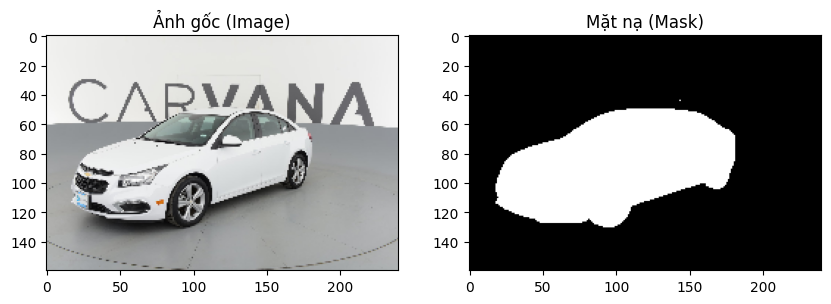

In [ ]:
# Trực quan hóa dữ lệu
import matplotlib.pyplot as plt

# Lấy 1 lô dữ liệu gồm 16 cặp ảnh/mask
images, masks = next(iter(train_loader))

# Chọn ảnh đầu tiên trong lô để hiển thị
# images[0]: Lấy tấm ảnh đầu tiên trong số 16 tấm
# .permute(1, 2, 0): PyTorch thích để định dạng là [Kênh màu, Cao, Rộng] nhưng thư viện matplotlib lại bắt buộc phải là [Cao, Rộng, Kênh màu] -> Lệnh này giúp xoay các chiều dữ liệu lại cho đúng ý thư viện vẽ
# Chuyển từ dạng "Tensor" (dùng cho AI) về dạng "Numpy"
img = images[0].permute(1, 2, 0).numpy() # Chuyển từ [C, H, W] về [H, W, C] để vẽ
msk = masks[0].numpy()

plt.figure(figsize=(10, 5)) # Tạo một cái khung ảnh rộng 10, cao 5

plt.subplot(1, 2, 1) # Chia khung tranh làm 1 hàng, 2 cột. Số 1 cuối cùng nghĩa là vẽ vào ô đầu tiên (bên trái
plt.title("Ảnh gốc (Image)")
plt.imshow(img) # Lệnh này chính thức "đổ màu" bức ảnh lên ô đó

plt.subplot(1, 2, 2) # Vẽ vào ô thứ hai (bên phải)
plt.title("Mặt nạ (Mask)")
plt.imshow(msk, cmap="gray") # Vẽ cái mặt nạ. Vì mặt nạ chỉ có 0 và 1 (đen và trắng), nên ta dùng cmap="gray" để nó hiện ra đúng màu trắng đen cho dễ nhìn

plt.show()

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [ ]:
# Khởi tạo class
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Nhánh đi xuống (Encoder - Thu nhỏ ảnh)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64,128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128,256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256,512))
        # Đáy của chữ U
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512,1024))

        # Nhánh đi lên (Decoder - Phóng to ảnh)
        # Chúng ta dùng ConvTranspose2d để phóng to x2
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2,stride=2)
        self.conv_up1 = DoubleConv(1024, 512) # 512 (từ up) + 512 (từ skip) = 1024
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2,stride=2)
        self.conv_up2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2,stride=2)
        self.conv_up3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2,stride=2)
        self.conv_up4 = DoubleConv(128, 64)
        # Lớp cuối cùng: Đưa về số lượng class mong muốn (ví dụ 1 cho nhị phân)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # 1. Giai đoạn đi xuống và lưu lại bản sao để làm Skip Connection
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        # 2. Giai đoạn đi lên kết hợp Skip Connection
        # Phóng to x5, rồi nối với x4
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1) # Nối theo chiều dọc (kênh màu)
        x = self.conv_up1(x)
        # Lặp lại cho các tầng tiếp theo
        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)
        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)
        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)
        logits = self.outc(x)
        return logits

In [ ]:
import torch.optim as optim

# 1. Chọn thiết bị (ưu tiên GPU trên Kaggle)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang dùng thiết bị: {device}")

# 2. Khởi tạo mô hình (Dùng class UNet bạn đã viết trước đó)
# n_channels=3 (RGB), n_classes=1 (Binary segmentation)
model = UNet(n_channels=3, n_classes=1).to(device)

# 3. Hàm lỗi và Bộ tối ưu hóa
# BCEWithLogitsLoss rất tốt cho phân đoạn nhị phân
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Đang dùng thiết bị: cuda


In [ ]:
from tqdm import tqdm # Thư viện để hiện thanh tiến trình

NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    model.train()
    loop = tqdm(train_loader)
    epoch_loss = 0

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device)
        # Thêm một chiều cho targets để thành [batch, 1, H, W]
        targets = targets.float().unsqueeze(1).to(device)

        # Forward pass: Dự đoán
        predictions = model(data)
        loss = loss_fn(predictions, targets)

        # Backward pass: Sửa sai
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Cập nhật thanh tiến trình
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] hoàn tất. Loss trung bình: {epoch_loss/len(train_loader):.4f}")

100%|██████████| 318/318 [04:56<00:00,  1.07it/s, loss=0.136]


Epoch [1/3] hoàn tất. Loss trung bình: 0.2096


100%|██████████| 318/318 [05:10<00:00,  1.02it/s, loss=0.0772]


Epoch [2/3] hoàn tất. Loss trung bình: 0.1049


100%|██████████| 318/318 [05:08<00:00,  1.03it/s, loss=0.0529]

Epoch [3/3] hoàn tất. Loss trung bình: 0.0637


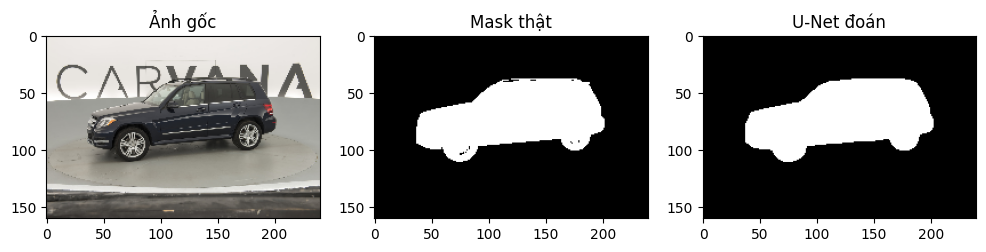

In [ ]:
model.eval()
with torch.no_grad():
    # Lấy 1 ảnh từ loader
    x, y = next(iter(train_loader))
    x = x.to(device)

    # Dự đoán
    preds = torch.sigmoid(model(x)) # Dùng sigmoid để đưa về khoảng 0-1
    preds = (preds > 0.5).float()   # Ngưỡng 0.5 để quyết định pixel đó là xe hay nền

# Vẽ kết quả ảnh đầu tiên trong lô
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Ảnh gốc"); plt.imshow(x[0].cpu().permute(1,2,0))
plt.subplot(1, 3, 2); plt.title("Mask thật"); plt.imshow(y[0].cpu(), cmap="gray")
plt.subplot(1, 3, 3); plt.title("U-Net đoán"); plt.imshow(preds[0].cpu().squeeze(), cmap="gray")
plt.show()